## Imports

In [1]:
import numpy as np
import pandas as pd

import sklearn as sk
from sklearn import base
from sklearn import calibration
from sklearn import cluster
from sklearn import compose
from sklearn import covariance
from sklearn import cross_decomposition
from sklearn import datasets
from sklearn import decomposition
from sklearn import discriminant_analysis
from sklearn import dummy
from sklearn import ensemble
from sklearn import exceptions
from sklearn import experimental
from sklearn import feature_extraction
from sklearn import feature_selection
from sklearn import gaussian_process
from sklearn import impute
from sklearn import inspection
from sklearn import isotonic
from sklearn import kernel_approximation
from sklearn import kernel_ridge
from sklearn import linear_model
from sklearn import manifold
from sklearn import metrics
from sklearn import mixture
from sklearn import model_selection
from sklearn import multiclass
from sklearn import multioutput
from sklearn import naive_bayes
from sklearn import neighbors
from sklearn import neural_network
from sklearn import pipeline
from sklearn import preprocessing
from sklearn import random_projection
from sklearn import semi_supervised
from sklearn import svm
from sklearn import tree
from sklearn import utils

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Analisi

## Es. 0

In [2]:
df = pd.read_csv('dataset.csv', sep=',')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## Es.1
Quante sono le istanze contenute nel dataset? _____ Il dataset è completo (cioè per 
ogni istanza tutti i valori di ogni attributo sono sempre correttamente specificati – non 
esistono “missing values”)? _____  Il dataset è bilanciato per quanto riguarda la classe da 
predire? ______ (punti 1)

In [3]:
print('Rows (instances):', df.shape[0])

Rows (instances): 7043


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Not balanced, much more non-churn than churn.

## Es. 2
Verificare se i clienti con contratto a lungo termine (Contract="Two year") hanno in 
media  una  spesa  mensile  (MonthlyCharges)  inferiore  rispetto  a  quelli con contratti 
mensili o annuali. (punti 2)

In [6]:
longterm = df[df['Contract'] == 'Two year']
others = df[df['Contract'] != 'Two year']

lt_mean = longterm['MonthlyCharges'].mean()
o_mean = others['MonthlyCharges'].mean()

print(lt_mean)
print(o_mean)
print(lt_mean < o_mean)

60.77041297935103
66.02669222139117
True


## Es. 3
Discretizzare tenure (anzianità del cliente) in 3 gruppi (bassa, media, alta). Creare 
una  tabella  pivot  che  mostri  la  percentuale  di  abbandono  (Churn)  per  gruppo  di 
anzianità e tipo di contratto. I clienti con anzianità bassa e contratto mensile hanno una 
probabilità maggiore di abbandonare? (punti 3) 

In [7]:
tenure_discr = pd.cut(df['tenure'], 3, labels=['bassa', 'media', 'alta'])
tenure_discr

0       bassa
1       media
2       bassa
3       media
4       bassa
        ...  
7038    bassa
7039     alta
7040    bassa
7041    bassa
7042     alta
Name: tenure, Length: 7043, dtype: category
Categories (3, object): ['bassa' < 'media' < 'alta']

In [8]:
df['tenure'] = tenure_discr
df['tenure']

0       bassa
1       media
2       bassa
3       media
4       bassa
        ...  
7038    bassa
7039     alta
7040    bassa
7041    bassa
7042     alta
Name: tenure, Length: 7043, dtype: category
Categories (3, object): ['bassa' < 'media' < 'alta']

In [9]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}) # Churn now a boolean column

In [10]:
pt = df.pivot_table(index=['tenure', 'Contract'], values='Churn', aggfunc=['sum', 'count']) # two agg functions at the same time
pt

/var/folders/ph/t7gwl3k17_l0cxktc3ll17600000gn/T/ipykernel_6209/2909912098.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pt = df.pivot_table(index=['tenure', 'Contract'], values='Churn', aggfunc=['sum', 'count']) # two agg functions at the same time
/var/folders/ph/t7gwl3k17_l0cxktc3ll17600000gn/T/ipykernel_6209/2909912098.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pt = df.pivot_table(index=['tenure', 'Contract'], values='Churn', aggfunc=['sum', 'count']) # two agg functions at the same time


sum count
                      Churn Churn
tenure Contract                  
bassa  Month-to-month  1302  2731
       One year          29   321
       Two year           0   158
media  Month-to-month   264   802
       One year          55   518
       Two year           6   274
alta   Month-to-month    89   342
       One year          82   634
       Two year          42  1263

In [11]:
pt['churn_rate_per_category'] = pt['sum']/pt['count']
pt

sum count churn_rate_per_category
                      Churn Churn                        
tenure Contract                                          
bassa  Month-to-month  1302  2731                0.476748
       One year          29   321                0.090343
       Two year           0   158                0.000000
media  Month-to-month   264   802                0.329177
       One year          55   518                0.106178
       Two year           6   274                0.021898
alta   Month-to-month    89   342                0.260234
       One year          82   634                0.129338
       Two year          42  1263                0.033254

In [12]:
# Shorter solution - note that the mean applied to a boolean sequence computes directly the probability of the positive, of 1.
pt_direct = pt = df.pivot_table(index=['tenure', 'Contract'], values='Churn', aggfunc='mean')
pt_direct

/var/folders/ph/t7gwl3k17_l0cxktc3ll17600000gn/T/ipykernel_6209/605085413.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pt_direct = pt = df.pivot_table(index=['tenure', 'Contract'], values='Churn', aggfunc='mean')


Churn
tenure Contract                
bassa  Month-to-month  0.476748
       One year        0.090343
       Two year        0.000000
media  Month-to-month  0.329177
       One year        0.106178
       Two year        0.021898
alta   Month-to-month  0.260234
       One year        0.129338
       Two year        0.033254

In [13]:
pt_direct.style.format("{:.2%}")

I clienti con ('bassa', 'month-to-month') hanno la probabilità più alta di churn.

## Es. 4
Determinare  se  l’adozione  di  almeno  un  servizio  extra  (OnlineSecurity, 
OnlineBackup,  DeviceProtection,  TechSupport,  StreamingTV, 
StreamingMovies)  riduce  il tasso di abbandono. (punti 2) Creare una nuova feature 
che conta il numero di servizi aggiuntivi attivi per cliente e verificare con un grafico se il 
tasso di abbandono diminuisce all’aumentare del numero di servizi attivi. (punti 2)

In [14]:
df['OnlineSecurity'].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [15]:
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
mapping = {'Yes': 1, 'No': 0, 'No internet service' : 0}

for col in services:
    df[col] = df[col].map(mapping)
    print(df[col].isnull().sum())

df

0
0
0
0
0
0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,bassa,No,No phone service,DSL,0,...,0,0,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,media,Yes,No,DSL,1,...,1,0,0,0,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,bassa,Yes,No,DSL,1,...,0,0,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,media,No,No phone service,DSL,1,...,1,1,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,bassa,Yes,No,Fiber optic,0,...,0,0,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,bassa,Yes,Yes,DSL,1,...,1,1,1,1,One year,Yes,Mailed check,84.80,1990.5,0
7039,2234-XADUH,Female,0,Yes,Yes,alta,Yes,Yes,Fiber optic,0,...,1,0,1,1,One year,Yes,Credit card (automatic),103.20,7362.9,0
7040,4801-JZAZL,Female,0,Yes,Yes,bassa,No,No phone service,DSL,1,...,0,0,0,0,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,Yes,No,bassa,Yes,Yes,Fiber optic,0,...,0,0,0,0,Month-to-month,Yes,Mailed check,74.40,306.6,1


In [16]:
df[(df['OnlineSecurity']==1) | (df['OnlineBackup']==1) |
 (df['DeviceProtection']==1) | (df['TechSupport']==1) | (df['StreamingTV']==1) | (df['StreamingMovies']==1)]['Churn'].mean()

np.float64(0.28897180762852404)

In [17]:
df[(df['OnlineSecurity']==0) & (df['OnlineBackup']==0) &
 (df['DeviceProtection']==0) & (df['TechSupport']==0) & (df['StreamingTV']==0) & (df['StreamingMovies']==0)]['Churn'].mean()

np.float64(0.21406038756196485)

Risposta alla prima parte dell'esercizio: no, in media non diminuisce il churn avendo almeno un servizio.

In [18]:
df['ActiveServices'] = df[services].sum(axis=1)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ActiveServices
0,7590-VHVEG,Female,0,Yes,No,bassa,No,No phone service,DSL,0,...,0,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,0,1
1,5575-GNVDE,Male,0,No,No,media,Yes,No,DSL,1,...,0,0,0,One year,No,Mailed check,56.95,1889.5,0,2
2,3668-QPYBK,Male,0,No,No,bassa,Yes,No,DSL,1,...,0,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,1,2
3,7795-CFOCW,Male,0,No,No,media,No,No phone service,DSL,1,...,1,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,0,3
4,9237-HQITU,Female,0,No,No,bassa,Yes,No,Fiber optic,0,...,0,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,bassa,Yes,Yes,DSL,1,...,1,1,1,One year,Yes,Mailed check,84.80,1990.5,0,5
7039,2234-XADUH,Female,0,Yes,Yes,alta,Yes,Yes,Fiber optic,0,...,0,1,1,One year,Yes,Credit card (automatic),103.20,7362.9,0,4
7040,4801-JZAZL,Female,0,Yes,Yes,bassa,No,No phone service,DSL,1,...,0,0,0,Month-to-month,Yes,Electronic check,29.60,346.45,0,1
7041,8361-LTMKD,Male,1,Yes,No,bassa,Yes,Yes,Fiber optic,0,...,0,0,0,Month-to-month,Yes,Mailed check,74.40,306.6,1,0


In [19]:
churn_rate = df['Churn'].groupby(df['ActiveServices']).mean()
churn_rate

ActiveServices
0    0.214060
1    0.457557
2    0.358180
3    0.273703
4    0.223005
5    0.124343
6    0.052817
Name: Churn, dtype: float64

<Axes: xlabel='Active Services', ylabel='Churn'>

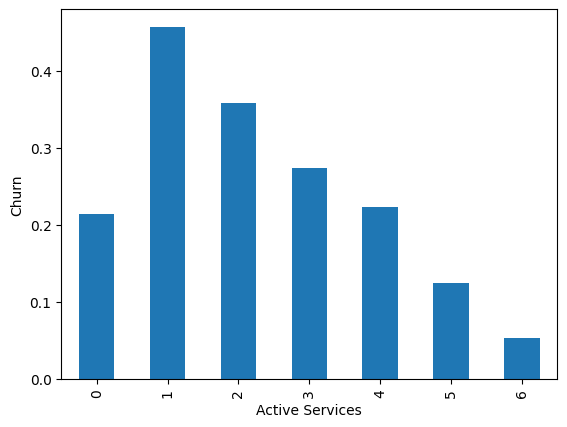

In [20]:
churn_rate.plot(kind='bar', xlabel='Active Services', ylabel='Churn')

Se si hanno dei servizi attivi, all'aumentare dei servizi diminuisce il tasso di abbandono.

# Trasformazione e predizione